# Thesis Figure 10 Ã¢â‚¬â€ Ground Truth IoU Visualisation

For one image and one desired length, produces four panels:
- **(a)** original image
- **(b)** ground-truth mask M_gt (binary, class pixels white)
- **(c)** predicted region mask M_R (UCB output, binary)
- **(d)** overlap M_R Ã¢Ë†Â© M_gt (green) and non-overlapping parts
  (blue = only M_gt, red = only M_R), with the IoU value printed.

Edit only the **Configuration** cell.

In [24]:
import json
import os
import re
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import torch.nn.functional as F
from mlflow.tracking import MlflowClient


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.imagenet_s import build_imagenet_s_mapping, get_object_mask, load_mask
from ciao.data.preprocessing import load_and_preprocess_image
from ciao.visualization.visualization import _to_hwc


# Ã¢â€â‚¬Ã¢â€â‚¬ MLflow Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
EXPERIMENT_NAME = "algorithm-comparison-imagenet-s"
os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

# Ã¢â€â‚¬Ã¢â€â‚¬ Image and paths Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
IMAGE_NAME = "imagenets_0107.jpg"
LOCAL_IMAGES_PATH = Path("REPO_ROOT/images/images")
LOCAL_MASKS_PATH = Path("REPO_ROOT/images/masks")  # ImageNet-S masks

# Ã¢â€â‚¬Ã¢â€â‚¬ CIAO settings Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
DESIRED_LENGTH = 30  # which UCB run to use for M_R

# Ã¢â€â‚¬Ã¢â€â‚¬ Visualisation Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# Colours for the overlap panel (RGB float [0,1])
COLOR_INTERSECTION = (0.1, 0.75, 0.1)  # green  Ã¢â‚¬â€ M_R Ã¢Ë†Â© M_gt
COLOR_ONLY_GT = (0.2, 0.4, 1.0)  # blue   Ã¢â‚¬â€ M_gt \ M_R
COLOR_ONLY_PRED = (0.9, 0.1, 0.1)  # red    Ã¢â‚¬â€ M_R \ M_gt
MASK_ALPHA = 0.6

# Ã¢â€â‚¬Ã¢â€â‚¬ Output Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
OUTPUT_DIR = Path("output/10_ground_truth_iou")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient(tracking_uri=TRACKING_URI)
_name_re = re.compile(r"^(?P<label>.+)-(?P<seed>\d+)-length-(?P<length>\d+)$")


def _npy(run_id: str, name: str) -> np.ndarray | None:
    try:
        with tempfile.TemporaryDirectory() as d:
            p = client.download_artifacts(run_id, name, dst_path=d)
            return np.load(p)
    except Exception:
        return None


def _json_art(run_id: str, path: str) -> dict | None:
    try:
        with tempfile.TemporaryDirectory() as d:
            p = client.download_artifacts(run_id, path, dst_path=d)
            with open(p) as f:
                return json.load(f)
    except Exception:
        return None


def _binary_mask(segs: np.ndarray, ids: list[int]) -> np.ndarray:
    m = np.zeros(segs.shape, dtype=bool)
    for s in ids:
        m |= segs == s
    return m


def _region_segments(run_id: str) -> list[list[int]]:
    regions, idx = [], 0
    while True:
        d = _json_art(run_id, f"region_{idx}/segments.json")
        if d is None:
            break
        regions.append(d["segments"])
        idx += 1
    return regions


def _color_overlay(
    img: np.ndarray, mask: np.ndarray, color: tuple[float, float, float], alpha: float
) -> np.ndarray:
    out = img.copy()
    tint = np.array(color, dtype=np.float32)
    out[mask] = out[mask] * (1 - alpha) + tint * alpha
    return out


def _save_single(img_np: np.ndarray, path: Path, dpi: int = 150) -> None:
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(img_np, interpolation="nearest")
    ax.axis("off")
    fig.tight_layout(pad=0)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0)
    fig.savefig(path.with_suffix(".pdf"), dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

In [26]:
# Ã¢â€â‚¬Ã¢â€â‚¬ 1. Find the UCB run for IMAGE_NAME at DESIRED_LENGTH Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    raise RuntimeError(f"Experiment '{EXPERIMENT_NAME}' not found")
all_runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id], output_format="pandas"
)

parents = all_runs[all_runs["tags.mlflow.parentRunId"].isna()].copy()
children = all_runs[all_runs["tags.mlflow.parentRunId"].notna()].copy()


def _parse(name):
    m = _name_re.match(str(name) if isinstance(name, str) else "")
    if not m:
        return None, None, None
    return m.group("label"), int(m.group("seed")), int(m.group("length"))


_p = parents["tags.mlflow.runName"].apply(_parse)
parents = parents.assign(
    label=_p.apply(lambda x: x[0]),
    desired_length=_p.apply(lambda x: x[2]),
)

merged = children.merge(
    parents[["run_id", "label", "desired_length"]].dropna(subset=["label"]),
    left_on="tags.mlflow.parentRunId",
    right_on="run_id",
    suffixes=("", "_parent"),
    how="inner",
)
merged["image_name"] = merged["tags.mlflow.runName"]
merged["desired_length"] = merged["desired_length"].astype(int)
ucb = merged[merged["label"] == "ucb"].copy()

ucb_lookup: dict[str, dict[int, str]] = {}
for _, r in ucb.iterrows():
    ucb_lookup.setdefault(r["image_name"], {})[r["desired_length"]] = r["run_id"]

run_id = ucb_lookup.get(IMAGE_NAME, {}).get(DESIRED_LENGTH)
if run_id is None:
    raise RuntimeError(
        f"No UCB run found for '{IMAGE_NAME}' at length={DESIRED_LENGTH}"
    )
print(f"UCB run_id: {run_id}")

# MLflow metrics (for cross-check)
run_row = ucb[ucb["run_id"] == run_id].iloc[0]
_iou_col = next((c for c in ["metrics.iou"] if c in run_row.index), None)
_cls_col = next(
    (
        c
        for c in ["params.class_name", "params.target_class_name"]
        if c in run_row.index
    ),
    None,
)
_cls_idx_col = next(
    (c for c in ["params.target_class_idx"] if c in run_row.index), None
)

print(f"Class: {run_row[_cls_col] if _cls_col else '?'}")
if _iou_col:
    print(f"IoU from MLflow metrics: {float(run_row[_iou_col]):.4f}")

UCB run_id: 1458e3f84ddb47fabe4f70a6a1598981
Class: English springer
IoU from MLflow metrics: 0.0973


In [27]:
from PIL import Image as PILImage
from torchvision import transforms as T


# Ã¢â€â‚¬Ã¢â€â‚¬ 1. Original image Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
device = torch.device("cpu")
img_tensor = load_and_preprocess_image(LOCAL_IMAGES_PATH / IMAGE_NAME, device=device)
img_np = _to_hwc(img_tensor.unsqueeze(0))  # [H, W, 3] float32 in [0,1]
H, W = img_np.shape[:2]
print(f"Image: {H}x{W}")

# Ã¢â€â‚¬Ã¢â€â‚¬ 2. Ground-truth mask M_gt (correct: same Resize+CenterCrop as preprocessing) Ã¢â€â‚¬
mask_path = LOCAL_MASKS_PATH / (Path(IMAGE_NAME).stem + ".png")
if not mask_path.exists():
    raise FileNotFoundError(
        f"Mask not found: {mask_path}\n"
        "Set LOCAL_MASKS_PATH to the ImageNet-S masks directory."
    )
gt_mask_raw = load_mask(mask_path)  # [H', W'] int32 tensor at original resolution

# Recover target class index
target_class_idx: int | None = None
if _cls_idx_col and run_row[_cls_idx_col] is not None:
    target_class_idx = int(run_row[_cls_idx_col])
if target_class_idx is None:
    run_info = client.get_run(run_id)
    tc = run_info.data.params.get("target_class_idx")
    target_class_idx = int(tc) if tc is not None else None

if target_class_idx is None:
    raise RuntimeError("Could not determine target_class_idx")
print(f"Target class idx: {target_class_idx}")

mapping = build_imagenet_s_mapping()
obj_mask = get_object_mask(gt_mask_raw, target_class_idx, mapping)
if obj_mask is None:
    raise RuntimeError(
        f"Class idx {target_class_idx} is not in ImageNet-S-919. "
        "The ground-truth mask cannot be extracted."
    )

# Ã¢â€â‚¬Ã¢â€â‚¬ Correct resize: Resize(256, NEAREST) + CenterCrop(224) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# This matches torchvision's image preprocessing pipeline exactly.
_mask_tfm = T.Compose(
    [
        T.Resize(256, interpolation=T.InterpolationMode.NEAREST),
        T.CenterCrop(224),
    ]
)


def _resize_mask_like_preprocessing(mask_bool_np: np.ndarray) -> np.ndarray:
    pil = PILImage.fromarray(mask_bool_np.astype(np.uint8) * 255, mode="L")
    pil = _mask_tfm(pil)
    return np.array(pil) > 0


gt_resized = _resize_mask_like_preprocessing(obj_mask.numpy())  # [224, 224] bool

# Ã¢â€â‚¬Ã¢â€â‚¬ Experiment IoU (what was logged to MLflow) used simple F.interpolate Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# Ã¢â€ â€™ scales the full original mask to 224x224 without applying the center crop.
# This does NOT align with the cropped image content.
gt_resized_experiment = (
    F.interpolate(
        obj_mask.float().unsqueeze(0).unsqueeze(0),
        size=(H, W),
        mode="nearest",
    )
    .squeeze()
    .bool()
    .numpy()
)

print(f"GT pixels (correct, with center crop): {int(gt_resized.sum())}")
print(f"GT pixels (experiment, no center crop): {int(gt_resized_experiment.sum())}")
print(
    f"Pixel difference: {int(np.abs(gt_resized.astype(int) - gt_resized_experiment.astype(int)).sum())}"
)

# Ã¢â€â‚¬Ã¢â€â‚¬ 3. Predicted region mask M_R Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
segs = _npy(run_id, "segments.npy")
if segs is None:
    raise RuntimeError("segments.npy not found in MLflow run")
reg_segs = _region_segments(run_id)
if not reg_segs:
    raise RuntimeError("No region segments found in MLflow run")

all_ids = [s for reg in reg_segs for s in reg]
pred_mask = _binary_mask(segs, all_ids)  # [H, W] bool
print(f"\nPredicted mask pixels: {int(pred_mask.sum())} / {H * W}")

# Ã¢â€â‚¬Ã¢â€â‚¬ 4. IoU Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
intersection = pred_mask & gt_resized
union = pred_mask | gt_resized
iou = float(intersection.sum()) / float(union.sum()) if union.sum() > 0 else 0.0

intersection_exp = pred_mask & gt_resized_experiment
union_exp = pred_mask | gt_resized_experiment
iou_experiment = (
    float(intersection_exp.sum()) / float(union_exp.sum())
    if union_exp.sum() > 0
    else 0.0
)

print(f"\nIoU (correct, center-crop GT):   {iou:.4f}")
print(f"IoU (experiment, no center crop): {iou_experiment:.4f}")
if _iou_col:
    print(
        f"IoU from MLflow metric:          {float(run_row[_iou_col]):.4f}  Ã¢â€ Â matches 'experiment' above"
    )

Image: 224x224
Target class idx: 217
GT pixels (correct, with center crop): 16956
GT pixels (experiment, no center crop): 10345
Pixel difference: 7803



Predicted mask pixels: 1249 / 50176

IoU (correct, center-crop GT):   0.0563
IoU (experiment, no center crop): 0.0366
IoU from MLflow metric:          0.0973  Ã¢â€ Â matches 'experiment' above


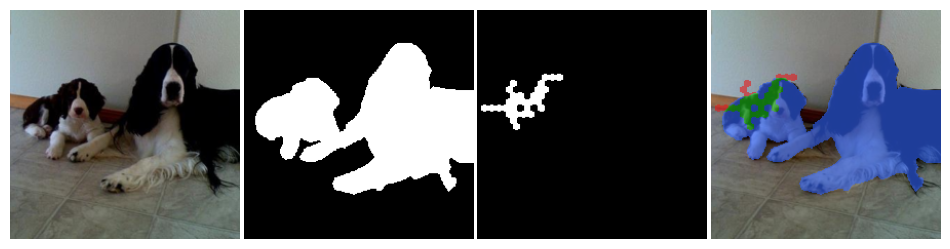

IoU = 0.0563
  intersection: 970 px
  union:        17235 px
  only GT:      15986 px
  only pred:    279 px


In [28]:
# Build the overlap/union visualisation panel
# Start from white background, paint union region, then colour-code each part
overlap_panel = img_np.copy()

# Green = intersection (highest priority)
overlap_panel = _color_overlay(
    overlap_panel, intersection, COLOR_INTERSECTION, MASK_ALPHA
)
# Blue = only in GT
only_gt = gt_resized & ~pred_mask
overlap_panel = _color_overlay(overlap_panel, only_gt, COLOR_ONLY_GT, MASK_ALPHA)
# Red = only in predicted
only_pred = pred_mask & ~gt_resized
overlap_panel = _color_overlay(overlap_panel, only_pred, COLOR_ONLY_PRED, MASK_ALPHA)

# GT mask as white-on-black binary image for display
gt_display = np.stack([gt_resized.astype(np.float32)] * 3, axis=-1)
pred_display = np.stack([pred_mask.astype(np.float32)] * 3, axis=-1)

panels = [img_np, gt_display, pred_display, overlap_panel]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, panel in zip(axes, panels, strict=False):
    ax.imshow(panel)
    ax.axis("off")

fig.subplots_adjust(wspace=0.02)
for sfx in [".png", ".pdf"]:
    fig.savefig(
        OUTPUT_DIR / f"iou_four_panel{sfx}",
        dpi=150,
        bbox_inches="tight",
        pad_inches=0.02,
    )
plt.show()
print(f"IoU = {iou:.4f}")
print(f"  intersection: {int(intersection.sum())} px")
print(f"  union:        {int(union.sum())} px")
print(f"  only GT:      {int(only_gt.sum())} px")
print(f"  only pred:    {int(only_pred.sum())} px")

In [29]:
img_dir = OUTPUT_DIR / Path(IMAGE_NAME).stem
img_dir.mkdir(parents=True, exist_ok=True)

_save_single(img_np, img_dir / "a_original.png")
_save_single(gt_display, img_dir / "b_gt_mask.png")
_save_single(pred_display, img_dir / f"c_pred_mask_l{DESIRED_LENGTH}.png")
_save_single(overlap_panel, img_dir / f"d_overlap_l{DESIRED_LENGTH}.png")

# Save a small text file with the IoU value
(img_dir / f"iou_l{DESIRED_LENGTH}.txt").write_text(
    f"IoU = {iou:.6f}\nintersection = {int(intersection.sum())}\nunion = {int(union.sum())}\n"
)

print(f"Saved panels to {img_dir}/")

Saved panels to output\10_ground_truth_iou\imagenets_0107/
